In [2]:
# Task 6 - Prepare Daily Sales Data

import pandas as pd
import matplotlib.pyplot as plt

# Load sales dataset
df = pd.read_csv("/content/sales.csv")

# Convert date to datetime
df["date"] = pd.to_datetime(df["date"])

# Remove missing values
df = df.dropna(subset=["date", "quantity"])

# Calculate total quantity sold per day
daily_sales = df.groupby("date")["quantity"].sum().reset_index()

# Sort by date
daily_sales = daily_sales.sort_values("date").reset_index(drop=True)

print("Daily Sales Data:")
display(daily_sales.head())

print("\nDaily Sales Shape:", daily_sales.shape)

Daily Sales Data:


,date,quantity
0,2022-08-28,35616.579
1,2022-08-29,41935.293
2,2022-08-30,40996.841
3,2022-08-31,43387.136
4,2022-09-01,50626.987



Daily Sales Shape: (761, 2)


In [3]:
# Task 6 - Insights Dashboard Summary

daily_sales["Month"] = daily_sales["date"].dt.to_period("M").astype(str)

print("Task 6 - Insights Dashboard")
print("----------------------------")
print("Total Days:", len(daily_sales))
print("Total Quantity Sold:", round(daily_sales["quantity"].sum(), 2))
print("Average Daily Sales:", round(daily_sales["quantity"].mean(), 2))
print("Maximum Daily Sales:", round(daily_sales["quantity"].max(), 2))

Task 6 - Insights Dashboard
----------------------------
Total Days: 761
Total Quantity Sold: 41938165.2
Average Daily Sales: 55109.28
Maximum Daily Sales: 154066.88


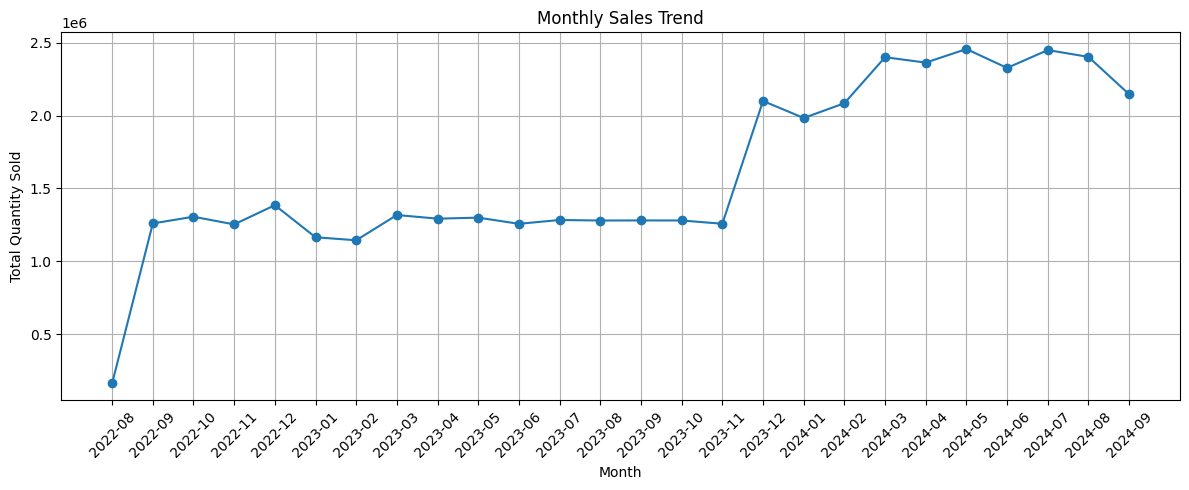

In [4]:
# 1. Monthly Sales Trend

monthly_sales = daily_sales.groupby("Month")["quantity"].sum().reset_index()

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["quantity"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Monthly Sales Trend:
The chart shows how total sales quantity changed from month to month. It helps identify periods of higher and lower sales and provides an overall view of the sales trend over time.

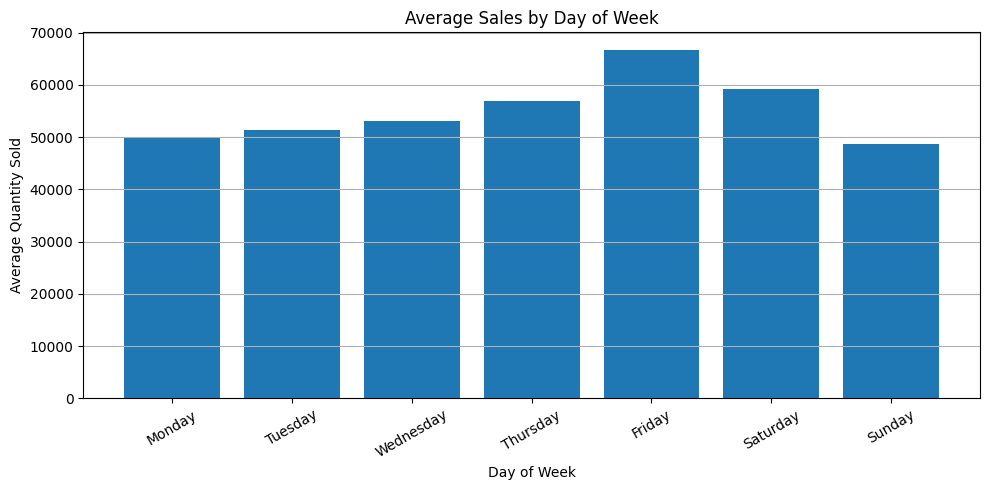

In [5]:
# 2. Day-wise Average Sales

daily_sales["Day"] = daily_sales["date"].dt.day_name()

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

day_average = (
    daily_sales.groupby("Day")["quantity"]
    .mean()
    .reindex(day_order)
    .reset_index()
)

plt.figure(figsize=(10, 5))

plt.bar(
    day_average["Day"],
    day_average["quantity"]
)

plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Quantity Sold")
plt.xticks(rotation=30)
plt.grid(axis="y")

plt.tight_layout()
plt.show()

Day-wise Average Sales:
This chart compares the average quantity sold on each day of the week. It helps identify which days generally have higher or lower sales activity.

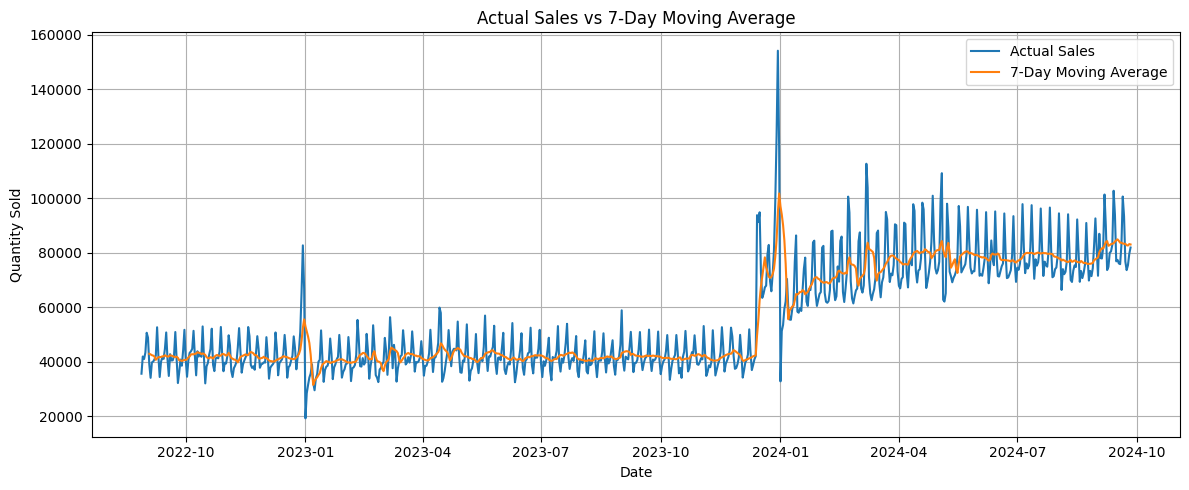

In [6]:
# 3. Actual Sales vs 7-Day Moving Average

daily_sales["Moving_Average_7"] = (
    daily_sales["quantity"].rolling(window=7).mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    daily_sales["date"],
    daily_sales["quantity"],
    label="Actual Sales"
)

plt.plot(
    daily_sales["date"],
    daily_sales["Moving_Average_7"],
    label="7-Day Moving Average"
)

plt.title("Actual Sales vs 7-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Quantity Sold")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Actual Sales vs 7-Day Moving Average:
The actual sales line shows daily fluctuations, while the 7-day moving average smooths these fluctuations and makes the overall sales trend easier to understand.

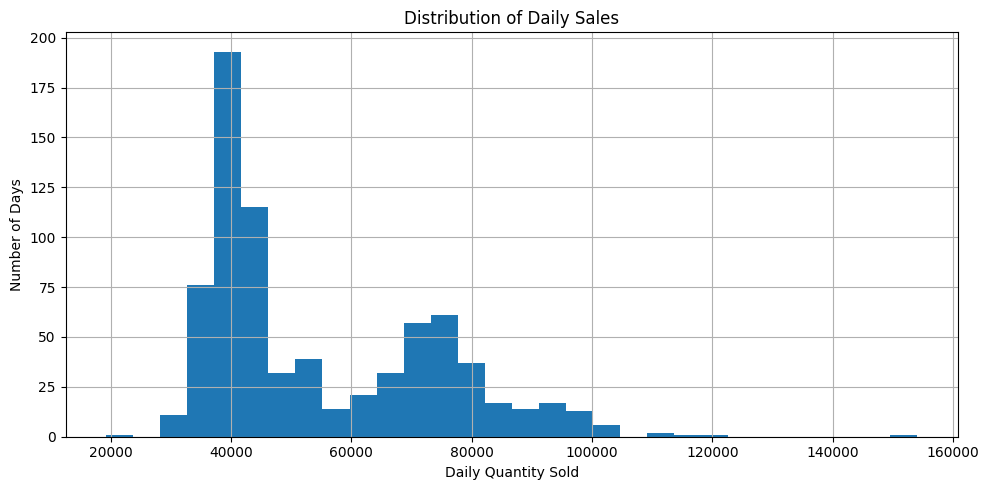

In [7]:
# 4. Sales Distribution

plt.figure(figsize=(10, 5))

plt.hist(
    daily_sales["quantity"],
    bins=30
)

plt.title("Distribution of Daily Sales")
plt.xlabel("Daily Quantity Sold")
plt.ylabel("Number of Days")
plt.grid(True)

plt.tight_layout()
plt.show()

Sales Distribution:
This histogram shows how daily sales quantities are distributed. Most days fall within the common sales range, while a few days show unusually high sales values.

## Task 6 – Insights Dashboard / Report

### Key Insights

1. Sales Trend:
Monthly sales show an overall increasing trend over the analyzed period. Sales increased significantly during the later months.

2. Best Sales Day:
Friday has the highest average daily sales, while Sunday has the lowest average sales. This indicates that sales activity is generally stronger toward the end of the working week.

3. Moving Average:
The 7-day moving average smooths the daily fluctuations and shows the overall sales trend more clearly. Sales levels increased considerably during 2024.

4. Sales Distribution:
Most daily sales values are concentrated in the lower-to-middle sales range. A few days have unusually high sales, which may represent peak sales periods.

### Overall Conclusion

The analysis shows that sales have generally increased over time. Friday is the strongest sales day, and the 7-day moving average confirms an upward trend. The business can use these insights to plan inventory, promotions, and staffing during high-sales periods.